<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

## DESARROLLO
Para corpus utlizaré una biliografía diferente, también de textos.info.

In [ ]:
import urllib.request
import bs4 as bs

### Dataset
Para el desarrollo de este trabajo práctico se utiliza como corpus la novela "Viaje al centro de la Tierra" de Julio Verne.

El texto se obtiene desde el mismo repositorio utilizado por la cátedra (https://www.textos.info).

In [3]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/viaje-al-centro-de-la-tierra/ebook')
raw_html = raw_html.read()

article_html = bs.BeautifulSoup(raw_html, 'lxml')
article_paragraphs = article_html.find_all('p')
article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

article_text = article_text.lower()

In [4]:
article_text[:1000]

' el domingo 24 de mayo de 1863, mi tío, el profesor lidenbrock, entró \nrápidamente a su hogar, situado en el número 19 de la könig‑strasse, una\n de las calles más tradicionales del barrio antiguo de hamburgo. marta, su excelente criada, se preocupó sobremanera, creyendo que se \nhabía retrasado, pues apenas empezaba a cocinar la comida en el \nhornillo. “bueno” —pensé para mí—, “si mi tío viene con hambre, se va a armar \nla de san quintín; porque no conozco a otro hombre de menos paciencia”. —¡tan temprano y ya está aquí el señor lidenbrock! —exclamó la pobre marta, con arrebol, entreabriendo la puerta del comedor. —sí, marta; pero tú no tienes la culpa de que la comida no esté lista\n todavía, porque es temprano, aún no son las dos. acaba de dar la media \nhora en san miguel. —¿y por qué ha venido tan pronto el señor lidenbrock? —él lo explicará, seguramente. —¡ahí viene! yo me escapo. señor axel, cálmelo usted, por favor. y la excelente marta se retiró presurosa a su recinto culi

### Elegir el tamaño del contexto

In [5]:

max_context_size = 50
#max_context_size = 100
#max_context_size = 100

In [6]:
from tensorflow.keras.utils import pad_sequences
chars_vocab = set(article_text)
len(chars_vocab)
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [7]:
tokenized_text = [char2idx[ch] for ch in article_text]

In [8]:
tokenized_text[:1000]

[48,
 11,
 74,
 48,
 40,
 62,
 46,
 25,
 47,
 53,
 62,
 48,
 8,
 34,
 48,
 40,
 11,
 48,
 46,
 60,
 49,
 62,
 48,
 40,
 11,
 48,
 65,
 50,
 69,
 51,
 43,
 48,
 46,
 25,
 48,
 72,
 42,
 62,
 43,
 48,
 11,
 74,
 48,
 33,
 23,
 62,
 56,
 11,
 64,
 62,
 23,
 48,
 74,
 25,
 40,
 11,
 47,
 70,
 23,
 62,
 1,
 10,
 43,
 48,
 11,
 47,
 72,
 23,
 5,
 48,
 63,
 23,
 32,
 33,
 25,
 40,
 60,
 46,
 11,
 47,
 72,
 11,
 48,
 60,
 48,
 64,
 59,
 48,
 44,
 62,
 53,
 60,
 23,
 43,
 48,
 64,
 25,
 72,
 59,
 60,
 40,
 62,
 48,
 11,
 47,
 48,
 11,
 74,
 48,
 47,
 12,
 46,
 11,
 23,
 62,
 48,
 65,
 22,
 48,
 40,
 11,
 48,
 74,
 60,
 48,
 10,
 54,
 47,
 25,
 53,
 4,
 64,
 72,
 23,
 60,
 64,
 64,
 11,
 43,
 48,
 59,
 47,
 60,
 63,
 48,
 40,
 11,
 48,
 74,
 60,
 64,
 48,
 1,
 60,
 74,
 74,
 11,
 64,
 48,
 46,
 32,
 64,
 48,
 72,
 23,
 60,
 40,
 25,
 1,
 25,
 62,
 47,
 60,
 74,
 11,
 64,
 48,
 40,
 11,
 74,
 48,
 70,
 60,
 23,
 23,
 25,
 62,
 48,
 60,
 47,
 72,
 25,
 53,
 59,
 62,
 48,
 40,
 11,
 48,
 44,
 60,
 

### Organizando y estructurando el dataset

In [9]:
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]
val_text = val_text[:20000]
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])
tokenized_sentences_val = [val_text[init:init+max_context_size] for init in range(len(val_text)-max_context_size+1)]

In [10]:
X.shape

(385534, 50)

In [11]:
X[0,:10]
y[0,:10]

array([11, 74, 48, 40, 62, 46, 25, 47, 53, 62])

In [12]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

- Para la resolución del trabajo se evaluará diferentes arquitecturas de redes neuronales recurrentes, utilizando tres variantes:
    1. SimpleRNN
    2. LSTM
    3. GRU.
    
    De esta forma se analizará el impacto del tipo de unidad recurrente en la capacidad del modelo para capturar patrones del lenguaje.

- Una vez entrenados los modelos, se seleccionará el que presente mejor desempeño para realizar la generación de texto.

- Sobre este modelo se implementarán distintas estrategias de generación de secuencias:

    1. Greedy search
    2. Beam search determinístico
    3. Beam search estocástico

    En el caso del beam search estocástico, se analizará además el efecto de la temperatura sobre la diversidad del texto generado.

In [24]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense, LSTM, GRU
from keras.models import Model, Sequential

In [14]:
def build_model(rnn_layer):
    model = Sequential()

    model.add(TimeDistributed(
        CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"),
        input_shape=(None,1)
    ))

    model.add(rnn_layer)
    model.add(Dense(vocab_size, activation='softmax'))

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='rmsprop'
    )

    return model

Se utilizará el callback proporcionado por la cátedra:

In [15]:
class PplCallback(keras.callbacks.Callback):

    def __init__(self, val_data, history_ppl, model_name, patience=5):
        self.val_data = val_data
        self.history_ppl = history_ppl
        self.model_name = model_name

        self.target = []
        self.padded = []

        count = 0
        self.info = []
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience

        for seq in self.val_data:

            len_seq = len(seq)
            indices = list(range(1, len_seq, 3))

            subseq = [seq[:i] for i in indices]
            self.target.extend([seq[i] for i in indices])

            if len(subseq) != 0:
                self.padded.append(
                    pad_sequences(subseq, maxlen=max_context_size, padding='pre')
                )

                n_subseq = len(subseq)
                self.info.append((count, count + n_subseq))
                count += n_subseq

        self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        scores = []
        predictions = self.model.predict(self.padded, batch_size=64, verbose=0)

        for start, end in self.info:

            probs = [
                predictions[idx_seq, -1, idx_vocab]
                for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])
            ]

            probs = np.clip(probs, 1e-10, 1.0)

            scores.append(np.exp(-np.mean(np.log(probs))))

        if len(scores) == 0:
            print("\n Warning: no scores computed \n")
            return

        current_score = np.mean(scores)
        self.history_ppl.append(current_score)

        print(f'\n mean perplexity: {current_score} \n')

        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(f"{self.model_name}.keras")
            print("Saved new model!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("Stopping training...")
                self.model.stop_training = True

### 1. Primer modelo a experimentar: SimpleRNN

In [16]:
print("Entrenando SimpleRNN...")

model = build_model(
    SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1)
)

history_ppl_rnn = []

model.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_rnn, model_name="rnn")]
)

Entrenando SimpleRNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4829
 mean perplexity: 6.977707386016846 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 2.2531
Epoch 2/20
1501/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0047
 mean perplexity: 5.964407444000244 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 1.9705
Epoch 3/20
1503/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8976
 mean perplexity: 5.641831398010254 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 1.8835
Epoch 4/20
1504/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8502
 mean perplexity: 5.437524318695068 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 1.8421
Epoch 5/20
1501/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8214
 mean perplexity: 5.302059650421143 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 1.8168
Epoch 6/20
1502/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8044
 mean perple

### Observaciones:
El modelo SimpleRNN muestra una mejora rápida en las primeras épocas, reduciendo la perplejidad de forma considerable. Sin embargo, a medida que avanza el entrenamiento, la mejora se vuelve más lenta y tiende a estabilizarse.

Esto indica que el modelo logra aprender patrones básicos del texto, pero tiene limitaciones para capturar dependencias más complejas o de largo alcance.


### 2. Segundo modelo a experimentar: LSTM

In [18]:
print("Entrenando LSTM...")

model = build_model(
    LSTM(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1)
)

history_ppl_lstm = []

model.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_lstm, model_name="lstm")]
)

Entrenando LSTM...
Epoch 1/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 2.7155
 mean perplexity: 8.466115951538086 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 252s 163ms/step - loss: 2.4461
Epoch 2/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 2.1671
 mean perplexity: 7.49001932144165 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 246s 164ms/step - loss: 2.1368
Epoch 3/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 2.0656
 mean perplexity: 7.018886089324951 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 246s 163ms/step - loss: 2.0473
Epoch 4/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 1.9971
 mean perplexity: 6.579619407653809 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 261s 163ms/step - loss: 1.9823
Epoch 5/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 1.9390
 mean perplexity: 6.2669758796691895 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 262s 163ms/step - loss: 1.9245
Epoch 6/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━

### Observaciones:

El modelo LSTM presenta una mejora sostenida a lo largo de todo el entrenamiento. A diferencia de la SimpleRNN, no se observa un estancamiento temprano, lo que sugiere una mayor capacidad para modelar dependencias de largo plazo en el texto.

La perplejidad disminuye de forma más progresiva y alcanza valores más bajos que en el modelo anterior.

Como contrapartida, el tiempo de entrenamiento es considerablemente mayor debido a la complejidad de la arquitectura.

### 3. Tercer modelo a experimentar: GRU

In [25]:
print("Entrenando GRU...")

model = build_model(
    GRU(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1)
)

history_ppl_gru = []

model.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_gru, model_name="gru")]
)

Entrenando GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 2.5431
 mean perplexity: 7.024354457855225 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 239s 156ms/step - loss: 2.2676
Epoch 2/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 1.9481
 mean perplexity: 5.576844215393066 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 242s 160ms/step - loss: 1.8924
Epoch 3/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 1.7591
 mean perplexity: 5.051163673400879 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 233s 155ms/step - loss: 1.7301
Epoch 4/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 1.6600
 mean perplexity: 4.806957244873047 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 233s 155ms/step - loss: 1.6428
Epoch 5/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 1.5999
 mean perplexity: 4.656239986419678 

Saved new model!
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 234s 155ms/step - loss: 1.5896
Epoch 6/20
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - lo

### Observaciones:
El modelo GRU logra la mejor performance entre los modelos evaluados. La perplejidad disminuye de forma sostenida y alcanza los valores más bajos.

El entrenamiento es estable, aunque se observan pequeñas fluctuaciones en algunas épocas, lo cual es esperable.

En términos generales, el modelo combina una buena capacidad de aprendizaje con una complejidad menor que LSTM, logrando un muy buen equilibrio entre desempeño y eficiencia.
El tiempo de entrenamiento fue similar al LSTM.

In [ ]:
# Clonar el repositorio
!git clone https://github.com/AlexCure/PLN-Desafio3.git

# Entrar a la carpeta del repo
%cd PLN-Desafio3

from google.colab import files
import pickle

In [28]:
# Desde el Repositorio de GitHub
with open("train_history/history_rnn.pkl", "rb") as f:
    history_ppl_rnn = pickle.load(f)

with open("train_history/history_lstm.pkl", "rb") as f:
    history_ppl_lstm = pickle.load(f)

with open("train_history/history_gru.pkl", "rb") as f:
    history_ppl_gru = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'train_history/history_rnn.pkl'

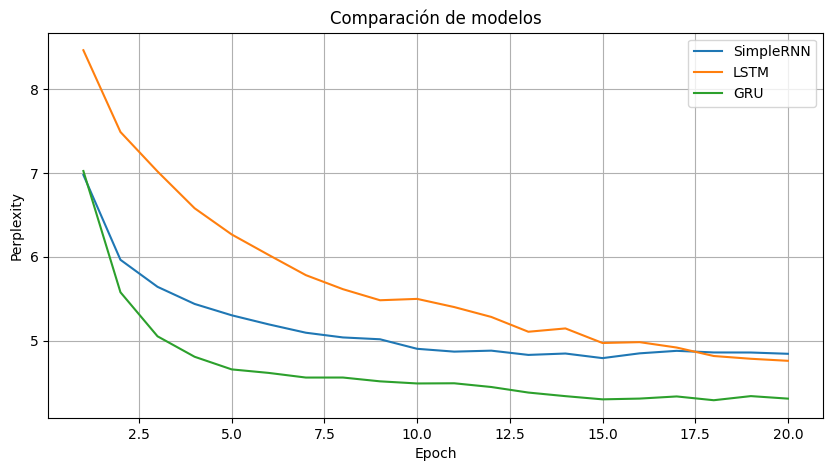

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.lineplot(x=range(1, len(history_ppl_rnn)+1), y=history_ppl_rnn, label="SimpleRNN")
sns.lineplot(x=range(1, len(history_ppl_lstm)+1), y=history_ppl_lstm, label="LSTM")
sns.lineplot(x=range(1, len(history_ppl_gru)+1), y=history_ppl_gru, label="GRU")

plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Comparación de modelos")
plt.legend()
plt.grid()

plt.show()

### Comparación de los modelos entrenados:

Para la comparación entre modelos se mantuvieron fijos los principales hiperparámetros de entrenamiento (cantidad de unidades, batch size, número de épocas, etc.). De esta forma, las diferencias observadas pueden atribuirse principalmente al tipo de arquitectura utilizada, lo que permite una comparación más justa.

Se evaluaron tres modelos recurrentes: SimpleRNN, LSTM y GRU.

El modelo SimpleRNN presenta el peor desempeño, mostrando limitaciones para capturar relaciones más complejas en el texto. El modelo LSTM mejora estos resultados, logrando una mejor representación del lenguaje, aunque con un mayor costo computacional.

Por último, el modelo GRU obtiene la menor perplejidad, mostrando un buen equilibrio entre calidad y eficiencia.

En base a estos resultados, **se selecciona el modelo GRU para la generación de texto**.

In [31]:
# ELEGIMOS EL MEJOR MODELO (EL QUE OBTUVO LA MEJOR PERPLEJIDAD) PARA GENERAR TEXTO NUEVO
model = keras.models.load_model('gru.keras')


### Predicción del próximo caracter

In [33]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [32]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d9ed65f1ec7dcd6a63.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 

### Generación de secuencias

In [34]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [35]:
input_text='habia una vez'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'habia una vez en la mano de la casa de la c'

###  Beam search y muestreo aleatorio

In [ ]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [ ]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [ ]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="habia una vez")

In [ ]:
salidas[0]

In [ ]:
# veamos las salidas
decode(salidas[0])